Exploratory Data Analysis for Pneumonia Detection from Chest X-Ray Images.

The goal of this notebook is to investigate the structure and properties of the
dataset before training a Convolutional Neural Network (CNN). The analysis
identifies issues such as class imbalance, unreliable dataset splits,
image inconsistencies, and potential data quality problems.

Insights obtained here will guide preprocessing, dataset restructuring,
and CNN architecture choices.


In [52]:
import tensorflow as tf

# Detect GPU
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU detected:", gpus)

    # prevent TensorFlow from allocating all GPU memory
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No GPU detected, using CPU")

GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [53]:
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Dataset path:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset path: /kaggle/input/chest-xray-pneumonia


In [54]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

In [55]:
!command -v tree >/dev/null 2>&1 || apt-get -qq install tree

In [56]:
!tree -d -L 3 {path}

/kaggle/input/chest-xray-pneumonia
└── chest_xray
    ├── chest_xray
    │   ├── test
    │   ├── train
    │   └── val
    ├── __MACOSX
    │   └── chest_xray
    ├── test
    │   ├── NORMAL
    │   └── PNEUMONIA
    ├── train
    │   ├── NORMAL
    │   └── PNEUMONIA
    └── val
        ├── NORMAL
        └── PNEUMONIA

16 directories


In [57]:
dataset_path = os.path.join(path, "chest_xray")

train_dir = os.path.join(dataset_path, "train")
val_dir = os.path.join(dataset_path, "val")
test_dir = os.path.join(dataset_path, "test")

splits = {
    "train": train_dir,
    "val": val_dir,
    "test": test_dir
}

classes = ["NORMAL", "PNEUMONIA"]

In [58]:
data = []

for split_name, split_path in splits.items():
    for cls in classes:
        folder = os.path.join(split_path, cls)
        count = len(os.listdir(folder))
        data.append([split_name, cls, count])

df = pd.DataFrame(data, columns=["Split", "Class", "Count"])
df

,Split,Class,Count
0,train,NORMAL,1341
1,train,PNEUMONIA,3875
2,val,NORMAL,8
3,val,PNEUMONIA,8
4,test,NORMAL,234
5,test,PNEUMONIA,390


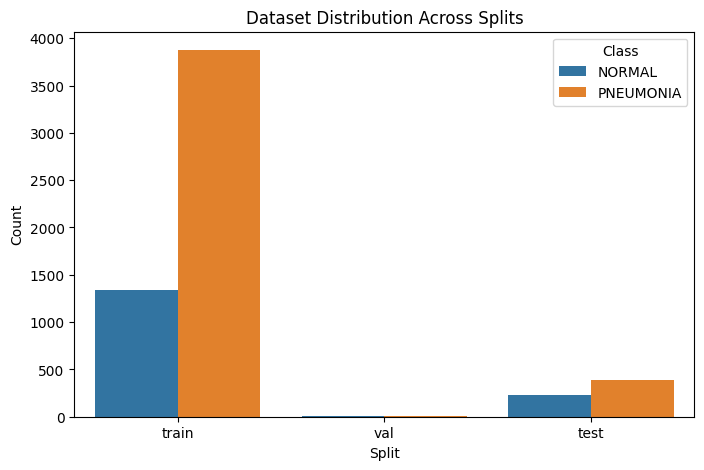

In [59]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Split",
    y="Count",
    hue="Class"
)

plt.title("Dataset Distribution Across Splits")
plt.show()

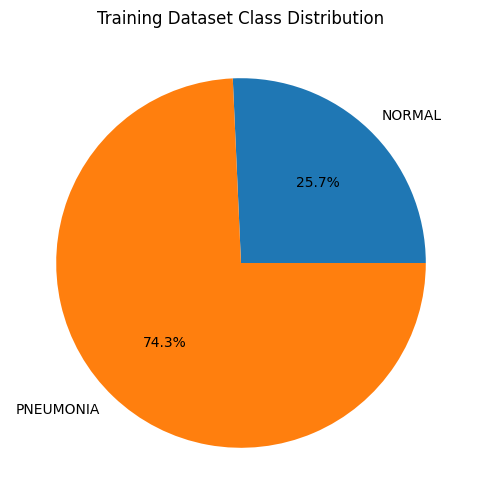

In [60]:
train_counts = df[df.Split == "train"]

plt.figure(figsize=(6,6))

plt.pie(
    train_counts["Count"],
    labels=train_counts["Class"],
    autopct='%1.1f%%'
)

plt.title("Training Dataset Class Distribution")
plt.show()

In [61]:
sizes = []

for cls in classes:
    folder = os.path.join(train_dir, cls)

    for img_file in os.listdir(folder)[:500]:

        img_path = os.path.join(folder, img_file)
        img = Image.open(img_path)

        sizes.append(img.size)

sizes = np.array(sizes)

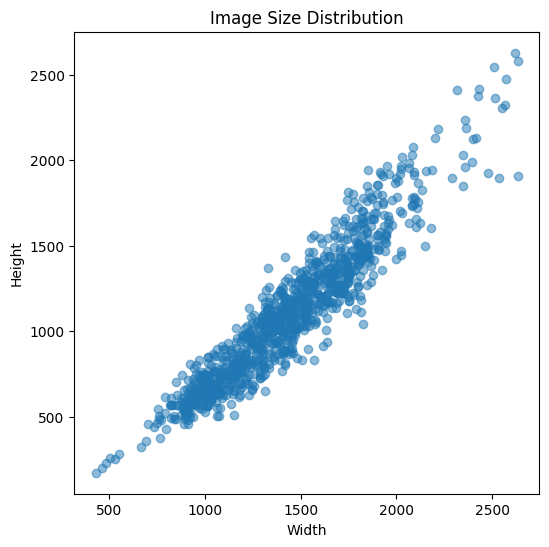

In [62]:
plt.figure(figsize=(6,6))

plt.scatter(sizes[:,0], sizes[:,1], alpha=0.5)

plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Size Distribution")

plt.show()

In [63]:
sample_image = Image.open(
    os.path.join(train_dir, "NORMAL",
    os.listdir(os.path.join(train_dir,"NORMAL"))[0])
)

print(sample_image.mode)

L


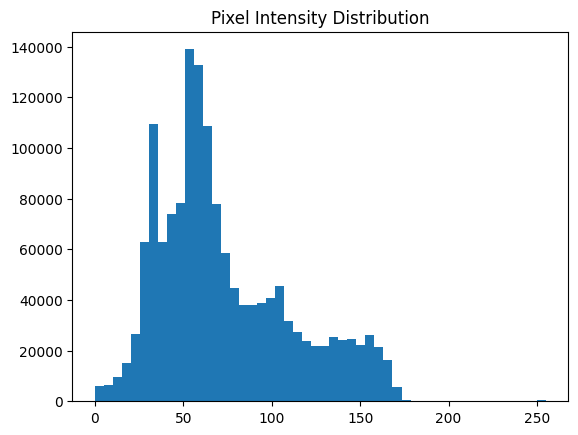

In [64]:
img_array = np.array(sample_image)

plt.hist(img_array.flatten(), bins=50)

plt.title("Pixel Intensity Distribution")

plt.show()

In [65]:
def show_samples(label):

    folder = os.path.join(train_dir, label)
    files = os.listdir(folder)[:5]

    plt.figure(figsize=(12,3))

    for i, file in enumerate(files):

        img = Image.open(os.path.join(folder, file))

        plt.subplot(1,5,i+1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")

    plt.suptitle(label)
    plt.show()

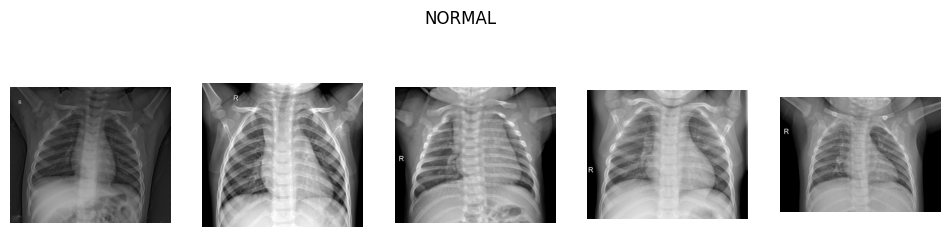

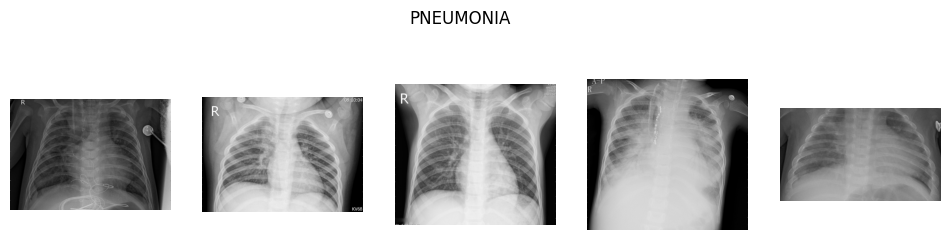

In [66]:
show_samples("NORMAL")
show_samples("PNEUMONIA")

In [67]:
corrupted = []

for split_name, split_path in splits.items():

    for cls in classes:

        folder = os.path.join(split_path, cls)

        for file in os.listdir(folder):

            path_img = os.path.join(folder, file)

            try:
                img = Image.open(path_img)
                img.verify()

            except:
                corrupted.append(path_img)

print("Corrupted images:", len(corrupted))

Corrupted images: 0


In [68]:
import hashlib

hashes = {}
duplicates = []

for split_name, split_path in splits.items():

    for cls in classes:

        folder = os.path.join(split_path, cls)

        for file in os.listdir(folder):

            path_img = os.path.join(folder, file)

            with open(path_img, "rb") as f:
                filehash = hashlib.md5(f.read()).hexdigest()

            if filehash in hashes:
                duplicates.append(path_img)
            else:
                hashes[filehash] = path_img

print("Duplicate images:", len(duplicates))

Duplicate images: 32


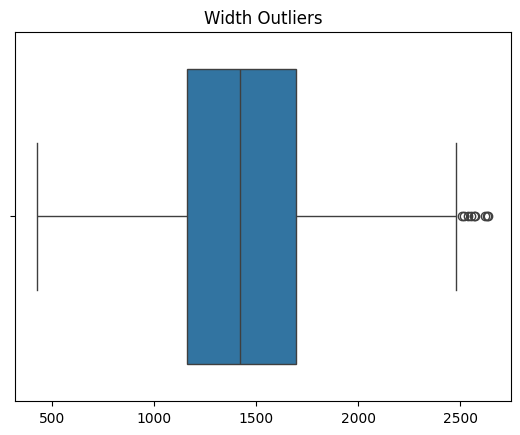

In [69]:
widths = sizes[:,0]
heights = sizes[:,1]

sns.boxplot(x=widths)
plt.title("Width Outliers")
plt.show()

In [70]:
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt
import seaborn as sns

def compute_brightness(folder, sample_size=300):

    brightness = []

    files = os.listdir(folder)[:sample_size]

    for file in files:

        img = Image.open(os.path.join(folder, file)).convert("L")
        img_array = np.array(img)

        brightness.append(img_array.mean())

    return brightness

In [71]:
normal_brightness = compute_brightness(os.path.join(train_dir,"NORMAL"))
pneumonia_brightness = compute_brightness(os.path.join(train_dir,"PNEUMONIA"))

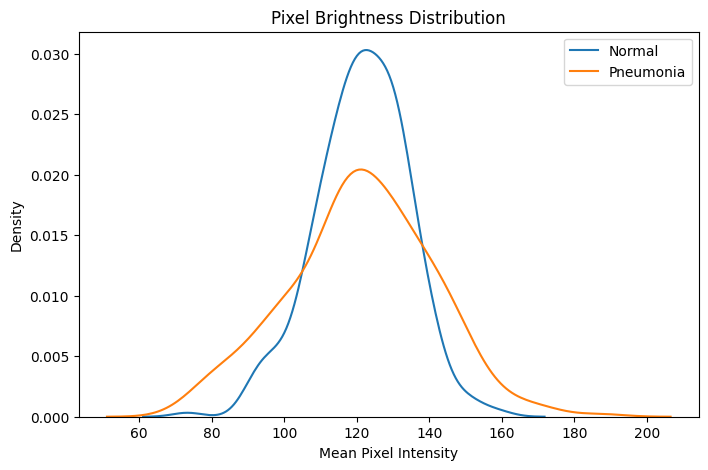

In [72]:
plt.figure(figsize=(8,5))

sns.kdeplot(normal_brightness, label="Normal")
sns.kdeplot(pneumonia_brightness, label="Pneumonia")

plt.title("Pixel Brightness Distribution")
plt.xlabel("Mean Pixel Intensity")
plt.legend()
plt.show()

In [73]:
from skimage.measure import shannon_entropy

def compute_entropy(folder, sample_size=300):

    entropy_values = []

    files = os.listdir(folder)[:sample_size]

    for file in files:

        img = Image.open(os.path.join(folder,file)).convert("L")
        img_array = np.array(img)

        entropy_values.append(shannon_entropy(img_array))

    return entropy_values

In [74]:
normal_entropy = compute_entropy(os.path.join(train_dir,"NORMAL"))
pneumonia_entropy = compute_entropy(os.path.join(train_dir,"PNEUMONIA"))

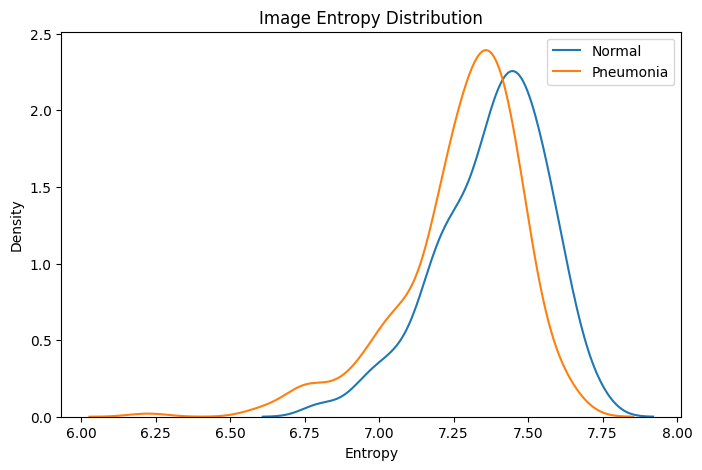

In [75]:
plt.figure(figsize=(8,5))

sns.kdeplot(normal_entropy,label="Normal")
sns.kdeplot(pneumonia_entropy,label="Pneumonia")

plt.title("Image Entropy Distribution")
plt.xlabel("Entropy")

plt.legend()
plt.show()

In [76]:
from skimage.feature import graycomatrix, graycoprops

def compute_texture(folder, sample_size=200):

    contrast_values = []

    files = os.listdir(folder)[:sample_size]

    for file in files:

        img = Image.open(os.path.join(folder,file)).convert("L")
        img_array = np.array(img)

        glcm = graycomatrix(
            img_array,
            distances=[5],
            angles=[0],
            levels=256,
            symmetric=True,
            normed=True
        )

        contrast = graycoprops(glcm,"contrast")[0,0]

        contrast_values.append(contrast)

    return contrast_values

In [77]:
normal_texture = compute_texture(os.path.join(train_dir,"NORMAL"))
pneumonia_texture = compute_texture(os.path.join(train_dir,"PNEUMONIA"))

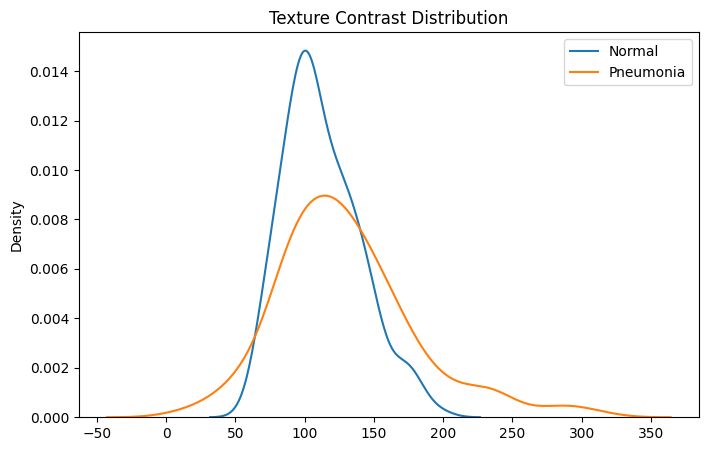

In [78]:
plt.figure(figsize=(8,5))

sns.kdeplot(normal_texture,label="Normal")
sns.kdeplot(pneumonia_texture,label="Pneumonia")

plt.title("Texture Contrast Distribution")

plt.legend()
plt.show()

In [79]:
import cv2

def compute_sharpness(folder, sample_size=300):

    sharpness_values = []

    files = os.listdir(folder)[:sample_size]

    for file in files:

        img = cv2.imread(os.path.join(folder,file), cv2.IMREAD_GRAYSCALE)

        laplacian_var = cv2.Laplacian(img, cv2.CV_64F).var()

        sharpness_values.append(laplacian_var)

    return sharpness_values

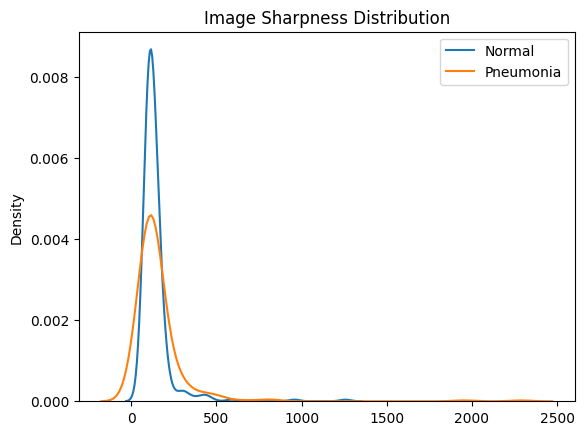

In [80]:
normal_sharp = compute_sharpness(os.path.join(train_dir,"NORMAL"))
pneumonia_sharp = compute_sharpness(os.path.join(train_dir,"PNEUMONIA"))

sns.kdeplot(normal_sharp,label="Normal")
sns.kdeplot(pneumonia_sharp,label="Pneumonia")

plt.title("Image Sharpness Distribution")
plt.legend()
plt.show()

In [81]:
def brightness_by_split(split_path):

    values = []

    for cls in classes:

        folder = os.path.join(split_path,cls)

        for file in os.listdir(folder)[:200]:

            img = Image.open(os.path.join(folder,file)).convert("L")
            values.append(np.array(img).mean())

    return values

In [82]:
train_brightness = brightness_by_split(train_dir)
test_brightness = brightness_by_split(test_dir)

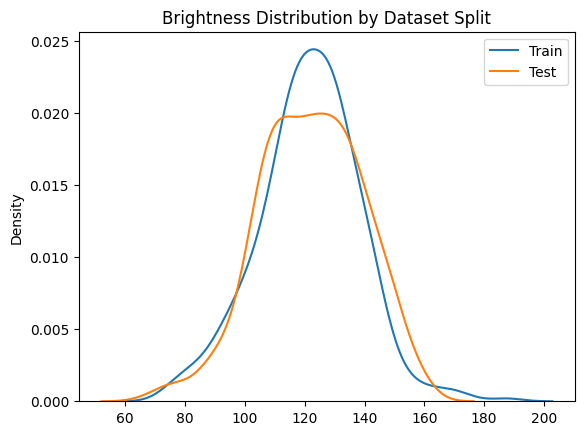

In [83]:
sns.kdeplot(train_brightness,label="Train")
sns.kdeplot(test_brightness,label="Test")

plt.title("Brightness Distribution by Dataset Split")
plt.legend()
plt.show()

The exploratory analysis revealed several important characteristics of the dataset:

Validation dataset is extremely small (16 images), making it unsuitable for reliable model selection. Therefore the validation set will be reconstructed from the training data.

Significant class imbalance exists, with pneumonia cases representing approximately 74% of the training data. Class weighting and data augmentation will be used to mitigate this issue.

Image dimensions vary considerably, requiring resizing to a consistent resolution before training.

Images are stored in grayscale format, and will be normalized and converted to a CNN-compatible representation.

These insights directly inform the design of the preprocessing pipeline and the architecture of the convolutional neural network used for pneumonia detection.

| Analysis     | Insight                         | Modelling Impact        |
| ------------ | ------------------------------- | ----------------------- |
| Brightness   | Pneumonia lungs appear brighter | Contrast normalization  |
| Entropy      | Pneumonia scans more complex    | CNN texture learning    |
| Texture      | Structural differences          | Deep feature extraction |
| Sharpness    | Variable image quality          | Robust augmentation     |
| Dataset bias | Potential distribution shift    | Careful normalization   |


Preprocessing

In [84]:
from sklearn.model_selection import train_test_split
from pathlib import Path

In [85]:
normal_paths = list(Path(path + "/chest_xray/train/NORMAL").glob("*.jpeg"))
pneumonia_paths = list(Path(path + "/chest_xray/train/PNEUMONIA").glob("*.jpeg"))

image_paths = normal_paths + pneumonia_paths
labels = [0]*len(normal_paths) + [1]*len(pneumonia_paths)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Total images:", len(image_paths))

Total images: 5216


In [86]:
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 3651
Validation: 782
Test: 783


In [87]:
IMG_SIZE = 224

def preprocess_image(path, label):

    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=1)

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [88]:
def augment(image, label):

    image = tf.image.random_flip_left_right(image)

    image = tf.image.random_brightness(image, 0.1)

    image = tf.image.random_contrast(image, 0.9, 1.1)

    image = tf.image.random_crop(
        tf.image.resize_with_pad(image, 230, 230),
        size=[224,224,1]
    )

    return image, label

In [89]:
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32

def build_dataset(paths, labels, training=False):

    paths = [str(p) for p in paths]

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    dataset = dataset.map(preprocess_image, num_parallel_calls=AUTOTUNE)

    if training:
        dataset = dataset.map(augment, num_parallel_calls=AUTOTUNE)
        dataset = dataset.shuffle(2000)

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

In [90]:
train_dataset = build_dataset(X_train, y_train, training=True)

val_dataset = build_dataset(X_val, y_val)

test_dataset = build_dataset(X_test, y_test)

In [91]:
train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [92]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.9440894568690097), 1: np.float64(0.6731194690265486)}


In [93]:
for images, labels in train_dataset.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 1)
(32,)


In [94]:
from tensorflow.keras import layers, models, regularizers

## Baseline Model

In [95]:
"""def se_block(inputs, reduction=16):

    filters = inputs.shape[-1]

    se = layers.GlobalAveragePooling2D()(inputs)
    se = layers.Dense(filters // reduction, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)

    se = layers.Reshape((1,1,filters))(se)

    return layers.Multiply()([inputs, se])
"""
def se_block(inputs, reduction):
    filters = inputs.shape[-1]
    se = layers.GlobalAveragePooling2D()(inputs)
    se = layers.Dense(filters // reduction, activation="relu")(se)
    se = layers.Dense(filters, activation="sigmoid")(se)
    se = layers.Reshape((1,1,filters))(se)
    return layers.Multiply()([inputs, se])

In [96]:
"""
def residual_block(x, filters, stride=1):

    shortcut = x

    x = layers.Conv2D(filters, 3, strides=stride, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    x = se_block(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    return x
"""
def residual_block(x, filters, stride=1, reduction=16, l2_reg=1e-4):
    shortcut = x
    x = layers.Conv2D(
        filters,
        3,
        strides=stride,
        padding="same",
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)
    x = layers.BatchNormalization()(x)
    x = se_block(x, reduction)
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters,1,strides=stride)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    return x

In [97]:
"""
def build_baseline_model(input_shape=(224,224,1)):

    inputs = layers.Input(shape=input_shape)

    # Initial feature extractor
    x = layers.Conv2D(32, 7, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)

    # Residual stages
    x = residual_block(x, 32)
    x = residual_block(x, 32)

    x = residual_block(x, 64, stride=2)
    x = residual_block(x, 64)

    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128)

    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256)

    # Global pooling
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.BatchNormalization()(x)

    x = layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)

    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)

    return model
"""
def build_baseline_model(input_shape=(224,224,1)):

    inputs = layers.Input(shape=input_shape)

    # Initial feature extractor
    x = layers.Conv2D(32, 7, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)

    # Residual stages
    x = residual_block(x, 32)
    x = residual_block(x, 32)

    x = residual_block(x, 64, stride=2)
    x = residual_block(x, 64)

    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128)

    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256)

    # Global pooling
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.BatchNormalization()(x)

    x = layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)

    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)

    return model


In [98]:
baseline_model = build_baseline_model()

baseline_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 112, 112,  │      1,600 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_17 (ReLU)     │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ re_lu_17[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 56, 56,    │      9,248 │ max_pooling2d_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        128 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_18 (ReLU)     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 56, 56,    │      9,248 │ re_lu_18[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        128 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 2)         │         66 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 32)        │         96 │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_8 (Reshape) │ (None, 1, 1, 32)  │          0 │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_8          │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Multiply)          │ 32)               │            │ reshape_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 56, 56,    │          0 │ multiply_8[0][0], │
│                     │ 32)               │            │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_19 (ReLU)     │ (None, 56, 56,    │          0 │ add_8[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 56, 56,    │      9,248 │ re_lu_19[0][0]  

 Total params: 2,859,773 (10.91 MB)

 Trainable params: 2,854,461 (10.89 MB)

 Non-trainable params: 5,312 (20.75 KB)

In [99]:
baseline_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss='binary_crossentropy',

    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

In [100]:
baseline_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss='binary_crossentropy',

    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

In [101]:
"""
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=5,
        min_lr=1e-6
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_cxr_model.h5",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]
"""
import os
from datetime import datetime

def get_callbacks(config=None):

    if config is None:
        config = {}

    early_patience = config.get("early_stopping_patience", 10)
    lr_patience = config.get("lr_reduce_patience", 5)
    lr_factor = config.get("lr_reduce_factor", 0.3)
    min_lr = config.get("min_lr", 1e-6)

    checkpoint_path = config.get("checkpoint_path", "best_baseline_model.keras")

    log_dir = config.get(
        "tensorboard_log_dir",
        os.path.join("logs", datetime.now().strftime("%Y%m%d-%H%M%S"))
    )

    callbacks = [

        tf.keras.callbacks.EarlyStopping(
            monitor='val_auc',
            mode="max",
            patience=early_patience,
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_auc',
            mode="max",
            factor=lr_factor,
            patience=lr_patience,
            min_lr=min_lr,
            verbose=1
        ),

        tf.keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1
        ),

        tf.keras.callbacks.TensorBoard(
            log_dir=log_dir,
            histogram_freq=1
        )
    ]

    return callbacks

In [102]:
callbacks = get_callbacks()
history = baseline_model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=30,

    class_weight=class_weights,

    callbacks=callbacks
)

Epoch 1/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.8109 - auc: 0.8987 - loss: 0.5913 - precision_3: 0.9500 - recall_3: 0.7909
Epoch 1: val_auc improved from -inf to 0.50258, saving model to best_baseline_model.keras
115/115 ━━━━━━━━━━━━━━━━━━━━ 82s 348ms/step - accuracy: 0.8113 - auc: 0.8991 - loss: 0.5906 - precision_3: 0.9501 - recall_3: 0.7914 - val_accuracy: 0.7430 - val_auc: 0.5026 - val_loss: 1.2046 - val_precision_3: 0.7430 - val_recall_3: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/30
114/115 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9133 - auc: 0.9750 - loss: 0.3979 - precision_3: 0.9816 - recall_3: 0.9007
Epoch 2: val_auc did not improve from 0.50258
115/115 ━━━━━━━━━━━━━━━━━━━━ 29s 164ms/step - accuracy: 0.9134 - auc: 0.9750 - loss: 0.3978 - precision_3: 0.9815 - recall_3: 0.9009 - val_accuracy: 0.7430 - val_auc: 0.5000 - val_loss: 2.4079 - val_precision_3: 0.7430 - val_recall_3: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/30
114/115 ━━━━━━━━━━━━━━━━━━━

In [103]:
test_results = baseline_model.evaluate(test_dataset)

for name, value in zip(baseline_model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 298ms/step - accuracy: 0.9800 - auc: 0.9961 - loss: 0.2720 - precision_3: 1.0000 - recall_3: 0.9728
loss: 0.2765
compile_metrics: 0.9745


In [104]:
test_loss, test_acc, test_auc, test_precision, test_recall = baseline_model.evaluate(test_dataset)

print("\nTest Performance")
print("---------------------")

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test AUC       : {test_auc:.4f}")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Recall    : {test_recall:.4f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - accuracy: 0.9800 - auc: 0.9961 - loss: 0.2720 - precision_3: 1.0000 - recall_3: 0.9728

Test Performance
---------------------
Test Loss      : 0.2765
Test Accuracy  : 0.9745
Test AUC       : 0.9964
Test Precision : 1.0000
Test Recall    : 0.9656


In [105]:
import numpy as np

y_true = []
y_pred_probs = []

for images, labels in test_dataset:
    preds = baseline_model.predict(images)

    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds.flatten())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

y_pred = (y_pred_probs > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


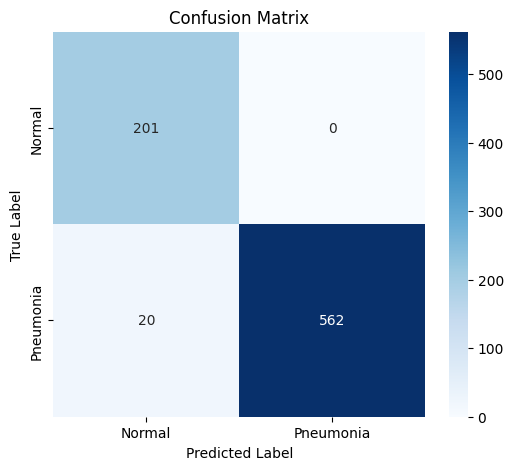

In [106]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Pneumonia"],
    yticklabels=["Normal","Pneumonia"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

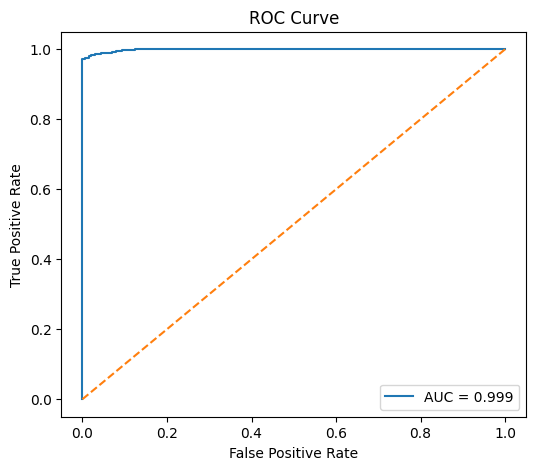

In [107]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [108]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [109]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:,0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap,0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [110]:
for img, label in test_dataset.take(1):
    test_image = img[0]
    break

img_array = np.expand_dims(test_image, axis=0)

In [112]:
import tensorflow as tf

last_conv_layer = None

for layer in reversed(baseline_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer.name
        break

print("Last conv layer:", last_conv_layer)

Last conv layer: conv2d_39


In [113]:
heatmap = make_gradcam_heatmap(
    img_array,
    baseline_model,
    last_conv_layer_name=last_conv_layer
)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_112']]
Received: inputs=Tensor(shape=(1, 224, 224, 1))
  warnings.warn(msg)


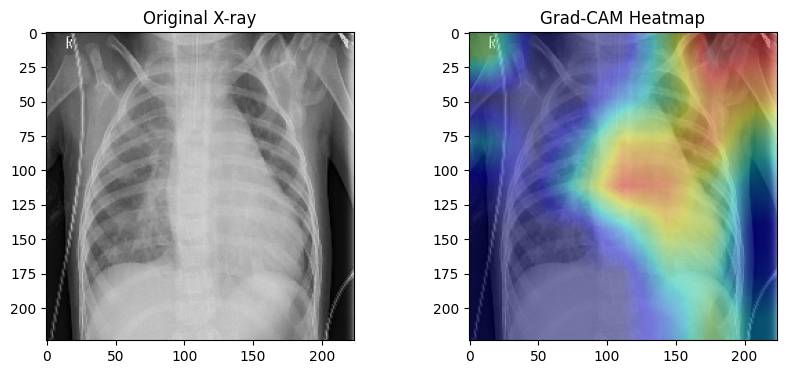

In [114]:
img = test_image.numpy().squeeze()

heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("Original X-ray")

plt.subplot(1,2,2)
plt.imshow(img, cmap="gray")
plt.imshow(heatmap, cmap="jet", alpha=0.4)
plt.title("Grad-CAM Heatmap")

plt.show()

In [115]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap,0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

In [116]:
for images, labels in test_dataset.take(1):
    test_image = images[0]
    break
img_array = np.expand_dims(test_image, axis=0)

In [118]:
heatmap = make_gradcam_heatmap(
    img_array,
    baseline_model,
    last_conv_layer_name=last_conv_layer
)

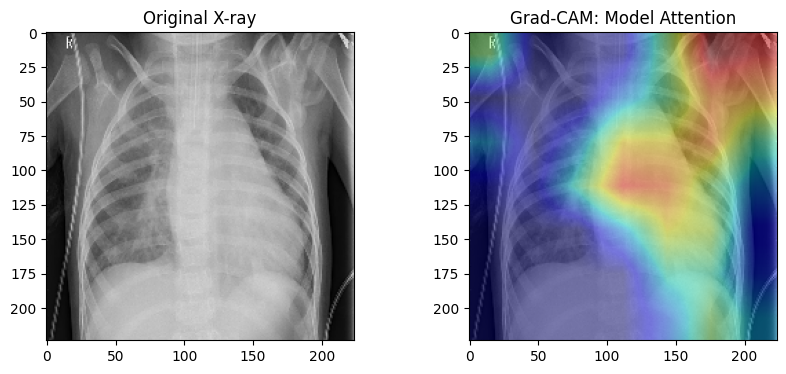

In [119]:
img = test_image.numpy().squeeze()

heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("Original X-ray")

plt.subplot(1,2,2)
plt.imshow(img, cmap="gray")
plt.imshow(heatmap, cmap="jet", alpha=0.4)
plt.title("Grad-CAM: Model Attention")

plt.show()

In [120]:
def tta_predict(baseline_model, image, n_augments=5):

    preds = []

    for i in range(n_augments):

        aug_img = tf.image.random_flip_left_right(image)
        aug_img = tf.image.random_brightness(aug_img, 0.1)
        aug_img = tf.image.random_contrast(aug_img, 0.9, 1.1)

        aug_img = tf.expand_dims(aug_img, axis=0)

        pred = baseline_model.predict(aug_img)

        preds.append(pred)

    return np.mean(preds)

In [121]:

"""
tta_predictions = []
tta_labels = []

for images, labels in test_dataset:

    for img, label in zip(images, labels):

        pred = tta_predict(baseline_model, img)

        tta_predictions.append(pred)
        tta_labels.append(label.numpy())
"""

'\ntta_predictions = []\ntta_labels = []\n\nfor images, labels in test_dataset:\n\n    for img, label in zip(images, labels):\n\n        pred = tta_predict(baseline_model, img)\n\n        tta_predictions.append(pred)\n        tta_labels.append(label.numpy())\n'

In [122]:

"""
tta_predictions = np.array(tta_predictions).flatten()

tta_labels = np.array(tta_labels)

tta_binary = (tta_predictions > 0.5).astype(int)
"""

'\ntta_predictions = np.array(tta_predictions).flatten()\n\ntta_labels = np.array(tta_labels)\n\ntta_binary = (tta_predictions > 0.5).astype(int)\n'

In [123]:
"""
from sklearn.metrics import accuracy_score

tta_acc = accuracy_score(tta_labels, tta_binary)

print("TTA Accuracy:", tta_acc)
"""

'\nfrom sklearn.metrics import accuracy_score\n\ntta_acc = accuracy_score(tta_labels, tta_binary)\n\nprint("TTA Accuracy:", tta_acc)\n'

## Hyperparams Tuned Model

In [124]:
"""
CONFIG = {

    "input_shape": (224, 224, 1),

    "conv_blocks": {
        "min": 3,
        "max": 5,
        "step": 1
    },

    "filters": [32, 64],

    "dropout": {
        "min": 0.3,
        "max": 0.6,
        "step": 0.1
    },

    "learning_rates": [1e-3, 5e-4, 1e-4],

    "dense_units": [64, 128],

    "epochs": 20,

    "max_trials": 20
}
"""
CONFIG = {

    "input_shape": (224, 224, 1),

    "num_stages": {
        "min": 3,
        "max": 4
    },

    "base_filters": [32, 64],

    "se_reduction": [8, 16],

    "dropout": {
        "min": 0.3,
        "max": 0.6,
        "step": 0.1
    },

    "dense_units": [64, 128, 256],

    "l2_reg": [1e-3, 1e-4, 1e-5],

    "learning_rates": [1e-3, 5e-4, 1e-4],

    "epochs": 20,

    "max_trials": 20
}

In [125]:
try:
    import keras_tuner as kt
except ImportError:
    !pip install -q keras-tuner
    import keras_tuner as kt

In [126]:
import tensorflow as tf
from tensorflow.keras import layers, models
import keras_tuner as kt

In [127]:
"""
def build_tuned_model(hp):

    inputs = layers.Input(shape=CONFIG["input_shape"])

    x = inputs

    # Number of convolution blocks
    num_blocks = hp.Int(
        "conv_blocks",
        min_value=CONFIG["conv_blocks"]["min"],
        max_value=CONFIG["conv_blocks"]["max"],
        step=CONFIG["conv_blocks"]["step"]
    )

    filters = hp.Choice("filters", CONFIG["filters"])

    for i in range(num_blocks):

        x = layers.Conv2D(
            filters,
            kernel_size=3,
            padding="same",
            activation="relu"
        )(x)

        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling2D()(x)

        filters *= 2

    x = layers.GlobalAveragePooling2D()(x)

    dropout_rate = hp.Float(
        "dropout",
        min_value=CONFIG["dropout"]["min"],
        max_value=CONFIG["dropout"]["max"],
        step=CONFIG["dropout"]["step"]
    )

    x = layers.Dropout(dropout_rate)(x)

    dense_units = hp.Choice(
        "dense_units",
        CONFIG["dense_units"]
    )

    x = layers.Dense(dense_units, activation="relu")(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)

    lr = hp.Choice(
        "learning_rate",
        CONFIG["learning_rates"]
    )

    model.compile(

        optimizer=tf.keras.optimizers.Adam(lr),

        loss="binary_crossentropy",

        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(),
            tf.keras.metrics.Recall()
        ]
    )

    return model
"""
def build_tuned_model(hp):

    inputs = layers.Input(shape=CONFIG["input_shape"])

    x = inputs

    base_filters = hp.Choice("base_filters", CONFIG["base_filters"])

    num_stages = hp.Int(
        "num_stages",
        min_value=CONFIG["num_stages"]["min"],
        max_value=CONFIG["num_stages"]["max"]
    )

    reduction = hp.Choice("se_reduction", CONFIG["se_reduction"])

    l2_reg = hp.Choice("l2_reg", CONFIG["l2_reg"])

    # Initial layer
    x = layers.Conv2D(base_filters,7,strides=2,padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(3,strides=2,padding="same")(x)

    filters = base_filters

    for stage in range(num_stages):

        x = residual_block(x, filters, stride=1, reduction=reduction, l2_reg=l2_reg)
        x = residual_block(x, filters, stride=1, reduction=reduction, l2_reg=l2_reg)

        filters *= 2

        if stage < num_stages - 1:
            x = residual_block(x, filters, stride=2, reduction=reduction, l2_reg=l2_reg)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.BatchNormalization()(x)

    dense_units = hp.Choice("dense_units", CONFIG["dense_units"])

    x = layers.Dense(
        dense_units,
        activation="relu",
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)

    dropout_rate = hp.Float(
        "dropout",
        min_value=CONFIG["dropout"]["min"],
        max_value=CONFIG["dropout"]["max"],
        step=CONFIG["dropout"]["step"]
    )

    x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)

    lr = hp.Choice("learning_rate", CONFIG["learning_rates"])

    model.compile(

        optimizer=tf.keras.optimizers.Adam(lr),

        loss="binary_crossentropy",

        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(),
            tf.keras.metrics.Recall()
        ]
    )

    return model

In [128]:
print("Not GridSearch but RandomSearch")
tuner = kt.RandomSearch(
    build_tuned_model,
    objective="val_accuracy",
    max_trials=CONFIG["max_trials"],
    directory="hyperparameter_search",
    project_name="pneumonia_cnn"
)

Not GridSearch but RandomSearch


In [ ]:
"""
tuner.search(
    train_dataset,
    validation_data=val_dataset,
    epochs=CONFIG["epochs"],
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=5
        )
    ]
)
"""
tuning_callbacks = get_callbacks({
    "early_stopping_patience": 8,
    "lr_reduce_patience": 3,
    "checkpoint_path": "tuner_best_model.keras"
})

# Add CSV logger
tuning_callbacks.append(tf.keras.callbacks.CSVLogger("training_log.csv"))

tuner.search(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=tuning_callbacks
)

Trial 12 Complete [00h 19m 04s]
val_accuracy: 0.9884910583496094

Best val_accuracy So Far: 0.9936061501502991
Total elapsed time: 03h 58m 34s

Search: Running Trial #13

Value             |Best Value So Far |Hyperparameter
32                |64                |base_filters
4                 |3                 |num_stages
8                 |8                 |se_reduction
0.001             |0.0001            |l2_reg
64                |256               |dense_units
0.5               |0.5               |dropout
0.001             |0.0005            |learning_rate

Epoch 1/30


In [ ]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best Hyperparameters Found:")

for hp_name in best_hps.values:

    print(f"{hp_name}: {best_hps.get(hp_name)}")

In [ ]:
best_model = tuner.hypermodel.build(best_hps)

"""
history = best_model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=50,

    callbacks=[

        tf.keras.callbacks.EarlyStopping(
            patience=10,
            restore_best_weights=True
        )
    ]
)
"""

In [ ]:
history = best_model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=30,

    class_weight=class_weights,

    callbacks=callbacks
)

In [ ]:
test_loss, test_acc, test_auc, test_precision, test_recall = best_model.evaluate(test_dataset)

In [ ]:
print("\nTest Performance")
print("---------------------")

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test AUC       : {test_auc:.4f}")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Recall    : {test_recall:.4f}")